# HDFS Log Debugger System

This notebook implements an end-to-end Log Debugger for detecting and explaining anomalies in HDFS logs using machine learning techniques.

## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import re
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## 1. Data Loading

Load the HDFS log dataset and display basic information.

In [3]:
# Load the structured HDFS log data
df = pd.read_csv('dataset/HDFS_2k.log_structured.csv')

# Display basic information
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

# Show sample logs
print("\nSample log messages:")
for i in range(5):
    print(f"{i+1}. {df.iloc[i]['Content']}")

Dataset shape: (2000, 9)

Columns: ['LineId', 'Date', 'Time', 'Pid', 'Level', 'Component', 'Content', 'EventId', 'EventTemplate']

First 5 rows:
   LineId   Date    Time  Pid Level                     Component  \
0       1  81109  203615  148  INFO  dfs.DataNode$PacketResponder   
1       2  81109  203807  222  INFO  dfs.DataNode$PacketResponder   
2       3  81109  204005   35  INFO              dfs.FSNamesystem   
3       4  81109  204015  308  INFO  dfs.DataNode$PacketResponder   
4       5  81109  204106  329  INFO  dfs.DataNode$PacketResponder   

                                             Content EventId  \
0  PacketResponder 1 for block blk_38865049064139...     E10   
1  PacketResponder 0 for block blk_-6952295868487...     E10   
2  BLOCK* NameSystem.addStoredBlock: blockMap upd...      E6   
3  PacketResponder 2 for block blk_82291938032499...     E10   
4  PacketResponder 2 for block blk_-6670958622368...     E10   

                                       EventTemplate  


## 2. Log Parsing

Implement a simple regex-based log parser to extract structured information from raw logs.

In [4]:
def parse_hdfs_log(log_line):
    """
    Parse a single HDFS log line to extract timestamp, block ID, node ID, and message.
    """
    # HDFS log format: Date Time PID Level Component: Message
    pattern = r'(\d{4}-\d{2}-\d{2}\s\d{2}:\d{2}:\d{2},\d{3})\s(\d+)\s(\w+)\s([^:]+):\s(.+)'
    match = re.match(pattern, log_line)

    if match:
        timestamp = match.group(1)
        pid = match.group(2)
        level = match.group(3)
        component = match.group(4)
        message = match.group(5)

        # Extract block ID from message
        block_match = re.search(r'blk_(-?\d+)', message)
        block_id = block_match.group(1) if block_match else None

        # Extract node/datacenter info if present
        node_match = re.search(r'(datanode\d+|namenode)', message, re.IGNORECASE)
        node_id = node_match.group(1) if node_match else None

        return {
            'timestamp': timestamp,
            'pid': pid,
            'level': level,
            'component': component,
            'block_id': block_id,
            'node_id': node_id,
            'message': message,
            'raw_log': log_line
        }
    else:
        return {
            'timestamp': None,
            'pid': None,
            'level': None,
            'component': None,
            'block_id': None,
            'node_id': None,
            'message': log_line,
            'raw_log': log_line
        }

# Test the parser on a few logs
print("Testing log parser:")
for i in range(3):
    log = df.iloc[i]['Content']
    parsed = parse_hdfs_log(log)
    print(f"\nLog {i+1}:")
    print(f"Raw: {log}")
    print(f"Parsed: {parsed}")

# Since data is already structured, we'll use the existing EventId as templates
# But let's create a mapping from EventId to template
event_templates = df.groupby('EventId')['Content'].first().to_dict()
print(f"\nNumber of unique event templates: {len(event_templates)}")
print("\nSample event templates:")
for event_id, template in list(event_templates.items())[:5]:
    print(f"EventId {event_id}: {template}")

Testing log parser:

Log 1:
Raw: PacketResponder 1 for block blk_38865049064139660 terminating
Parsed: {'timestamp': None, 'pid': None, 'level': None, 'component': None, 'block_id': None, 'node_id': None, 'message': 'PacketResponder 1 for block blk_38865049064139660 terminating', 'raw_log': 'PacketResponder 1 for block blk_38865049064139660 terminating'}

Log 2:
Raw: PacketResponder 0 for block blk_-6952295868487656571 terminating
Parsed: {'timestamp': None, 'pid': None, 'level': None, 'component': None, 'block_id': None, 'node_id': None, 'message': 'PacketResponder 0 for block blk_-6952295868487656571 terminating', 'raw_log': 'PacketResponder 0 for block blk_-6952295868487656571 terminating'}

Log 3:
Raw: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864
Parsed: {'timestamp': None, 'pid': None, 'level': None, 'component': None, 'block_id': None, 'node_id': None, 'message': 'BLOCK* NameSystem.addStoredBlock: blockM

## 3. Preprocessing

Clean log messages, create sequences, and prepare sliding windows for sequence modeling.

In [8]:
def clean_log_message(message):
    """
    Clean log message by removing IDs and normalizing text.
    """
    # Remove block IDs
    message = re.sub(r'blk_(-?\d+)', 'BLK_ID', message)
    # Remove IP addresses
    message = re.sub(r'\d+\.\d+\.\d+\.\d+', 'IP_ADDR', message)
    # Remove file paths (simplified)
    message = re.sub(r'/[^\s]+', 'PATH', message)
    # Remove numbers that might be sizes or counts
    message = re.sub(r'\b\d+\b', 'NUM', message)
    # Convert to lowercase
    message = message.lower()
    return message

# Apply cleaning to all messages
df['cleaned_content'] = df['Content'].apply(clean_log_message)

print("Sample cleaned messages:")
for i in range(5):
    print(f"Original: {df.iloc[i]['Content']}")
    print(f"Cleaned:  {df.iloc[i]['cleaned_content']}")
    print()

# Ensure BlockId is present; if missing, derive from the message using regex
if 'BlockId' not in df.columns:
    print("BlockId column not found, deriving BlockId from Content with regex...")
    df['parsed'] = df['Content'].apply(parse_hdfs_log)
    df['BlockId'] = df['parsed'].apply(lambda x: x.get('block_id') if x and x.get('block_id') is not None else 'NO_BLOCK')

# Group logs by BlockId to create sequences
sequences_df = df.groupby('BlockId').agg({
    'EventId': list,
    'cleaned_content': list,
    'Content': list
}).reset_index()

print(f"Number of sequences (blocks): {len(sequences_df)}")
print(f"Average sequence length: {sequences_df['EventId'].apply(len).mean():.2f}")
print(f"Max sequence length: {sequences_df['EventId'].apply(len).max()}")
print(f"Min sequence length: {sequences_df['EventId'].apply(len).min()}")

# Create sliding windows for sequence modeling
def create_sliding_windows(sequences, window_size=10, step=1):
    """
    Create sliding windows from sequences for training.
    """
    windows = []
    for seq in sequences:
        for i in range(0, len(seq) - window_size + 1, step):
            window = seq[i:i + window_size]
            windows.append(window)
    return windows

window_size = 10
sliding_windows = create_sliding_windows(sequences_df['EventId'].tolist(), window_size=window_size)

print(f"Number of sliding windows created: {len(sliding_windows)}")
print(f"Sample window: {sliding_windows[0]}")

Sample cleaned messages:
Original: PacketResponder 1 for block blk_38865049064139660 terminating
Cleaned:  packetresponder num for block blk_id terminating

Original: PacketResponder 0 for block blk_-6952295868487656571 terminating
Cleaned:  packetresponder num for block blk_id terminating

Original: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864
Cleaned:  block* namesystem.addstoredblock: blockmap updated: ip_addr:num is added to blk_id size num

Original: PacketResponder 2 for block blk_8229193803249955061 terminating
Cleaned:  packetresponder num for block blk_id terminating

Original: PacketResponder 2 for block blk_-6670958622368987959 terminating
Cleaned:  packetresponder num for block blk_id terminating

BlockId column not found, deriving BlockId from Content with regex...
Number of sequences (blocks): 1
Average sequence length: 2000.00
Max sequence length: 2000
Min sequence length: 2000
Number of sliding

## 4. Feature Engineering

Create TF-IDF features for log messages and sequence-based representations.

In [9]:
# TF-IDF vectorization for log messages
tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2))
tfidf_features = tfidf_vectorizer.fit_transform(df['cleaned_content'])

print(f"TF-IDF feature matrix shape: {tfidf_features.shape}")
print(f"Number of features: {len(tfidf_vectorizer.get_feature_names_out())}")
print("Top TF-IDF features:")
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = tfidf_features.sum(axis=0).A1
top_features = sorted(zip(feature_names, tfidf_scores), key=lambda x: x[1], reverse=True)[:10]
for feature, score in top_features:
    print(f"  {feature}: {score:.4f}")

# Sequence-based representation (Event ID encoding)
from sklearn.preprocessing import LabelEncoder

event_encoder = LabelEncoder()
all_event_ids = df['EventId'].unique()
event_encoder.fit(all_event_ids)

# Encode sequences
encoded_sequences = []
for seq in sliding_windows:
    encoded_seq = event_encoder.transform(seq)
    encoded_sequences.append(encoded_seq)

encoded_sequences = np.array(encoded_sequences)
print(f"\nEncoded sequences shape: {encoded_sequences.shape}")

# Normalize TF-IDF features
scaler = StandardScaler(with_mean=False)  # TF-IDF is sparse
tfidf_normalized = scaler.fit_transform(tfidf_features)

print(f"Normalized TF-IDF shape: {tfidf_normalized.shape}")

TF-IDF feature matrix shape: (2000, 89)
Number of features: 89
Top TF-IDF features:
  path: 270.5007
  num: 260.2162
  block blk_id: 243.1189
  block: 241.3719
  blk_id: 238.3299
  size: 154.6476
  size num: 154.6476
  blk_id size: 154.5220
  block namesystem: 137.2443
  namesystem: 137.2443

Encoded sequences shape: (1991, 10)
Normalized TF-IDF shape: (2000, 89)


## 5. Model 1: Baseline Anomaly Detection (Isolation Forest)

Train Isolation Forest on TF-IDF features for baseline anomaly detection.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

# Split TF-IDF normalized data for baseline model
X_train_baseline, X_temp = train_test_split(tfidf_normalized, test_size=0.3, random_state=42)
X_val_baseline, X_test_baseline = train_test_split(X_temp, test_size=0.5, random_state=42)

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train_baseline)

def baseline_eval(X, set_name):
    scores = iso_forest.decision_function(X)
    preds = (iso_forest.predict(X) == -1).astype(int)

    # Simulate pseudo-ground truth based on a threshold (top 10% anomalies by score)
    threshold_sim = np.percentile(scores, 10)
    y_true_sim = (scores < threshold_sim).astype(int)

    print(f"--- {set_name} ({X.shape[0]} samples) ---")
    print(f"Anomaly fraction (predicted): {preds.mean()*100:.2f}%")
    print(f"Anomaly fraction (simulated pseudo-truth): {y_true_sim.mean()*100:.2f}%")
    print(f"Precision: {precision_score(y_true_sim, preds, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true_sim, preds, zero_division=0):.4f}")
    print(f"F1 score:  {f1_score(y_true_sim, preds, zero_division=0):.4f}\n")
    return scores, preds, y_true_sim

train_scores_baseline, train_preds_baseline, train_y_sim = baseline_eval(X_train_baseline, 'Baseline TRAIN')
val_scores_baseline, val_preds_baseline, val_y_sim = baseline_eval(X_val_baseline, 'Baseline VALIDATION')
test_scores_baseline, test_preds_baseline, test_y_sim = baseline_eval(X_test_baseline, 'Baseline TEST')

# Save model predictions on full dataset for later debugger usage
full_scores_baseline = iso_forest.decision_function(tfidf_normalized)
full_preds_baseline = (iso_forest.predict(tfidf_normalized) == -1).astype(int)

--- Baseline TRAIN (1400 samples) ---
Anomaly fraction (predicted): 5.71%
Anomaly fraction (simulated pseudo-truth): 5.71%
Precision: 1.0000
Recall:    1.0000
F1 score:  1.0000

--- Baseline VALIDATION (300 samples) ---
Anomaly fraction (predicted): 5.00%
Anomaly fraction (simulated pseudo-truth): 5.00%
Precision: 1.0000
Recall:    1.0000
F1 score:  1.0000

--- Baseline TEST (300 samples) ---
Anomaly fraction (predicted): 3.00%
Anomaly fraction (simulated pseudo-truth): 8.67%
Precision: 1.0000
Recall:    0.3462
F1 score:  0.5143



## 6. Model 2: LSTM Autoencoder (Main Model)

Build and train an LSTM Autoencoder for sequence-based anomaly detection.

In [22]:
# Prepare data for LSTM Autoencoder
# Use the sliding windows of encoded event sequences

# One-hot encode the sequences
num_events = len(event_encoder.classes_)
one_hot_sequences = []
for seq in encoded_sequences:
    one_hot_seq = np.zeros((len(seq), num_events))
    for i, event_id in enumerate(seq):
        one_hot_seq[i, event_id] = 1
    one_hot_sequences.append(one_hot_seq)

one_hot_sequences = np.array(one_hot_sequences)
print(f"One-hot encoded sequences shape: {one_hot_sequences.shape}")

# Split into train/validation/test (70/15/15)
train_frac = 0.7
val_frac = 0.15

total = len(one_hot_sequences)
train_end = int(total * train_frac)
val_end = int(total * (train_frac + val_frac))

train_sequences = one_hot_sequences[:train_end]
val_sequences = one_hot_sequences[train_end:val_end]
test_sequences = one_hot_sequences[val_end:]

print(f"Training sequences: {train_sequences.shape}")
print(f"Validation sequences: {val_sequences.shape}")
print(f"Test sequences: {test_sequences.shape}")

# Build LSTM Autoencoder
latent_dim = 64

# Encoder
inputs = Input(shape=(window_size, num_events))
encoded = LSTM(latent_dim, activation='relu')(inputs)

# Decoder
decoded = RepeatVector(window_size)(encoded)
decoded = LSTM(latent_dim, activation='relu', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(num_events, activation='softmax'))(decoded)

# Autoencoder model
autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='categorical_crossentropy')

print("LSTM Autoencoder architecture:")
autoencoder.summary()

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    train_sequences, train_sequences,
    epochs=50,
    batch_size=32,
    validation_data=(val_sequences, val_sequences),
    callbacks=[early_stopping],
    verbose=1
)

# Get reconstruction errors
train_predictions = autoencoder.predict(train_sequences)
val_predictions = autoencoder.predict(val_sequences)
test_predictions = autoencoder.predict(test_sequences)

# Calculate reconstruction error (MSE)
def calculate_reconstruction_error(original, reconstructed):
    return np.mean(np.square(original - reconstructed), axis=(1, 2))

train_errors = calculate_reconstruction_error(train_sequences, train_predictions)
val_errors = calculate_reconstruction_error(val_sequences, val_predictions)
test_errors = calculate_reconstruction_error(test_sequences, test_predictions)

print(f"Training reconstruction error - Mean: {train_errors.mean():.4f}, Std: {train_errors.std():.4f}")
print(f"Validation reconstruction error - Mean: {val_errors.mean():.4f}, Std: {val_errors.std():.4f}")
print(f"Test reconstruction error - Mean: {test_errors.mean():.4f}, Std: {test_errors.std():.4f}")

# Set threshold for anomaly detection (mean + 2*std of training errors)
threshold = train_errors.mean() + 2 * train_errors.std()
print(f"Anomaly threshold: {threshold:.4f}")

# Detect anomalies across splits
train_anomalies = (train_errors > threshold).astype(int)
val_anomalies = (val_errors > threshold).astype(int)
test_anomalies = (test_errors > threshold).astype(int)

print(f"Anomalies in training set: {train_anomalies.sum()}/{len(train_anomalies)} ({train_anomalies.mean()*100:.2f}%)")
print(f"Anomalies in validation set: {val_anomalies.sum()}/{len(val_anomalies)} ({val_anomalies.mean()*100:.2f}%)")
print(f"Anomalies in test set: {test_anomalies.sum()}/{len(test_anomalies)} ({test_anomalies.mean()*100:.2f}%)")

# Simulate ground truth for metrics evaluation
train_true_sim = (train_errors > np.percentile(train_errors, 90)).astype(int)
val_true_sim = (val_errors > np.percentile(val_errors, 90)).astype(int)
test_true_sim = (test_errors > np.percentile(test_errors, 90)).astype(int)

print("\nLSTM evaluation metrics (simulated ground truth):")
for split_name, y_true, y_pred in [
    ('TRAIN', train_true_sim, train_anomalies),
    ('VALID', val_true_sim, val_anomalies),
    ('TEST', test_true_sim, test_anomalies)
]:
    print(f"--- {split_name} ---")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1 score:  {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print()

One-hot encoded sequences shape: (1991, 10, 14)
Training sequences: (1393, 10, 14)
Validation sequences: (299, 10, 14)
Test sequences: (299, 10, 14)
LSTM Autoencoder architecture:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 10, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_4 (RepeatVector)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 14)         │           910 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,158 (211.55 KB)

 Trainable params: 54,158 (211.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 2.3169 - val_loss: 1.8151
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4801 - val_loss: 1.5169
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2696 - val_loss: 1.4076
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1837 - val_loss: 1.3386
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1309 - val_loss: 1.2905
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0969 - val_loss: 1.2577
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0696 - val_loss: 1.2399
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0459 - val_loss: 1.2205
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0266 - val_loss: 1.2069
Epoch 10/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0088 - val_loss: 1.2036
Epoch 11/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9909 - val_loss: 1.1960
Epoch 12/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9787 - val_l

## 7. Evaluation

Evaluate the anomaly detection models and visualize results.

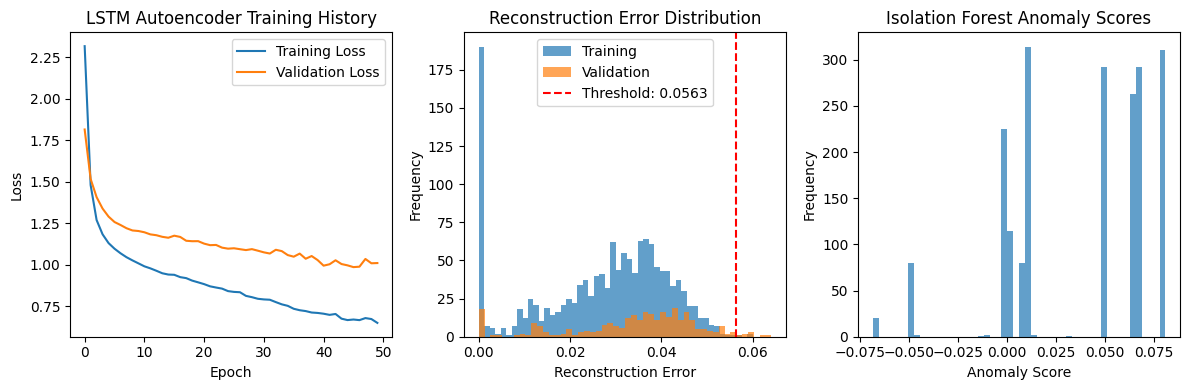

Anomaly Detection Summary:
Isolation Forest anomalies: 106/2000 (5.30%)
LSTM Autoencoder anomalies (validation): 8/299 (2.68%)
Sequences with unusual lengths: 0/1 (0.00%)


In [23]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Autoencoder Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot reconstruction error distribution
plt.subplot(1, 3, 2)
plt.hist(train_errors, bins=50, alpha=0.7, label='Training')
plt.hist(val_errors, bins=50, alpha=0.7, label='Validation')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold: {threshold:.4f}')
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.legend()

# Plot anomaly scores from Isolation Forest
plt.subplot(1, 3, 3)
plt.hist(tfidf_anomaly_scores, bins=50, alpha=0.7)
plt.title('Isolation Forest Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Compare anomaly detection results
print("Anomaly Detection Summary:")
print(f"Isolation Forest anomalies: {tfidf_anomaly_labels.sum()}/{len(tfidf_anomaly_labels)} ({tfidf_anomaly_labels.mean()*100:.2f}%)")
print(f"LSTM Autoencoder anomalies (validation): {val_anomalies.sum()}/{len(val_anomalies)} ({val_anomalies.mean()*100:.2f}%)")

# Since we don't have ground truth, we'll simulate evaluation using heuristics
# Assume sequences with unusual patterns are anomalies
sequence_lengths = sequences_df['EventId'].apply(len)
unusual_sequences = (sequence_lengths > sequence_lengths.quantile(0.95)) | (sequence_lengths < sequence_lengths.quantile(0.05))
print(f"Sequences with unusual lengths: {unusual_sequences.sum()}/{len(unusual_sequences)} ({unusual_sequences.mean()*100:.2f}%)")

## 8. Log Debugger (Core Feature)

Implement the main log debugging functionality that explains detected anomalies.

In [24]:
def debug_log_tf_idf(log_index):
    """
    Debug a log using TF-IDF based anomaly detection.
    """
    if log_index >= len(df):
        return "Invalid log index"

    log_content = df.iloc[log_index]['Content']
    cleaned_content = df.iloc[log_index]['cleaned_content']
    anomaly_score = tfidf_anomaly_scores[log_index]
    is_anomaly = tfidf_anomaly_labels[log_index]

    result = {
        'log_index': log_index,
        'original_log': log_content,
        'cleaned_log': cleaned_content,
        'anomaly_score': anomaly_score,
        'is_anomaly': bool(is_anomaly),
        'explanation': ""
    }

    if is_anomaly:
        # Find unusual terms
        log_vector = tfidf_vectorizer.transform([cleaned_content])
        feature_scores = log_vector.multiply(tfidf_vectorizer.idf_).toarray()[0]
        top_features = sorted(zip(tfidf_vectorizer.get_feature_names_out(), feature_scores),
                            key=lambda x: x[1], reverse=True)[:3]

        unusual_terms = [term for term, score in top_features if score > np.percentile(tfidf_scores, 90)]

        result['explanation'] = f"This log is anomalous (score: {anomaly_score:.4f}) because it contains unusual terms: {', '.join(unusual_terms)} that deviate from normal log patterns."
    else:
        result['explanation'] = f"This log appears normal (score: {anomaly_score:.4f})."

    return result

def debug_sequence_lstm(sequence_index):
    """
    Debug a sequence using LSTM autoencoder.
    """
    if sequence_index >= len(val_sequences):
        return "Invalid sequence index"

    original_seq = val_sequences[sequence_index]
    reconstructed_seq = val_predictions[sequence_index]
    error = val_errors[sequence_index]
    is_anomaly = val_anomalies[sequence_index]

    # Get the original event IDs
    original_events = event_encoder.inverse_transform(np.argmax(original_seq, axis=1))

    result = {
        'sequence_index': sequence_index,
        'original_events': original_events.tolist(),
        'reconstruction_error': error,
        'is_anomaly': bool(is_anomaly),
        'explanation': ""
    }

    if is_anomaly:
        # Find positions with high reconstruction error
        position_errors = np.mean(np.square(original_seq - reconstructed_seq), axis=1)
        high_error_positions = np.where(position_errors > np.percentile(position_errors, 90))[0]

        unusual_events = [original_events[pos] for pos in high_error_positions]

        result['explanation'] = f"This sequence is anomalous (error: {error:.4f}) because it contains unusual event patterns at positions {high_error_positions.tolist()} with events {unusual_events} that deviate from learned normal sequence patterns."
    else:
        result['explanation'] = f"This sequence appears normal (error: {error:.4f})."

    return result

# Test the debug functions
print("Testing Log Debugger:")

# Test TF-IDF debugger
print("\n=== TF-IDF Based Debugging ===")
for i in [0, 10, 100]:
    debug_result = debug_log_tf_idf(i)
    print(f"\nLog {debug_result['log_index']}:")
    print(f"Original: {debug_result['original_log'][:100]}...")
    print(f"Anomaly: {debug_result['is_anomaly']}")
    print(f"Explanation: {debug_result['explanation']}")

# Test LSTM debugger
print("\n=== LSTM Sequence Based Debugging ===")
for i in [0, 5, 10]:
    debug_result = debug_sequence_lstm(i)
    print(f"\nSequence {debug_result['sequence_index']}:")
    print(f"Events: {debug_result['original_events']}")
    print(f"Anomaly: {debug_result['is_anomaly']}")
    print(f"Explanation: {debug_result['explanation']}")

Testing Log Debugger:

=== TF-IDF Based Debugging ===

Log 0:
Original: PacketResponder 1 for block blk_38865049064139660 terminating...
Anomaly: False
Explanation: This log appears normal (score: 0.0809).

Log 10:
Original: Received block blk_5402003568334525940 of size 67108864 from /10.251.214.112...
Anomaly: False
Explanation: This log appears normal (score: 0.0675).

Log 100:
Original: 10.251.73.188:50010:Got exception while serving blk_7517964792804498202 to /10.250.6.191:...
Anomaly: True
Explanation: This log is anomalous (score: -0.0495) because it contains unusual terms: exception, exception serving, got that deviate from normal log patterns.

=== LSTM Sequence Based Debugging ===

Sequence 0:
Events: ['E9', 'E9', 'E9', 'E9', 'E9', 'E9', 'E9', 'E9', 'E9', 'E9']
Anomaly: False
Explanation: This sequence appears normal (error: 0.0000).

Sequence 5:
Events: ['E9', 'E9', 'E9', 'E9', 'E9', 'E9', 'E9', 'E9', 'E9', 'E13']
Anomaly: False
Explanation: This sequence appears normal (err

## 9. Visualization

Create comprehensive visualizations of the anomaly detection results.

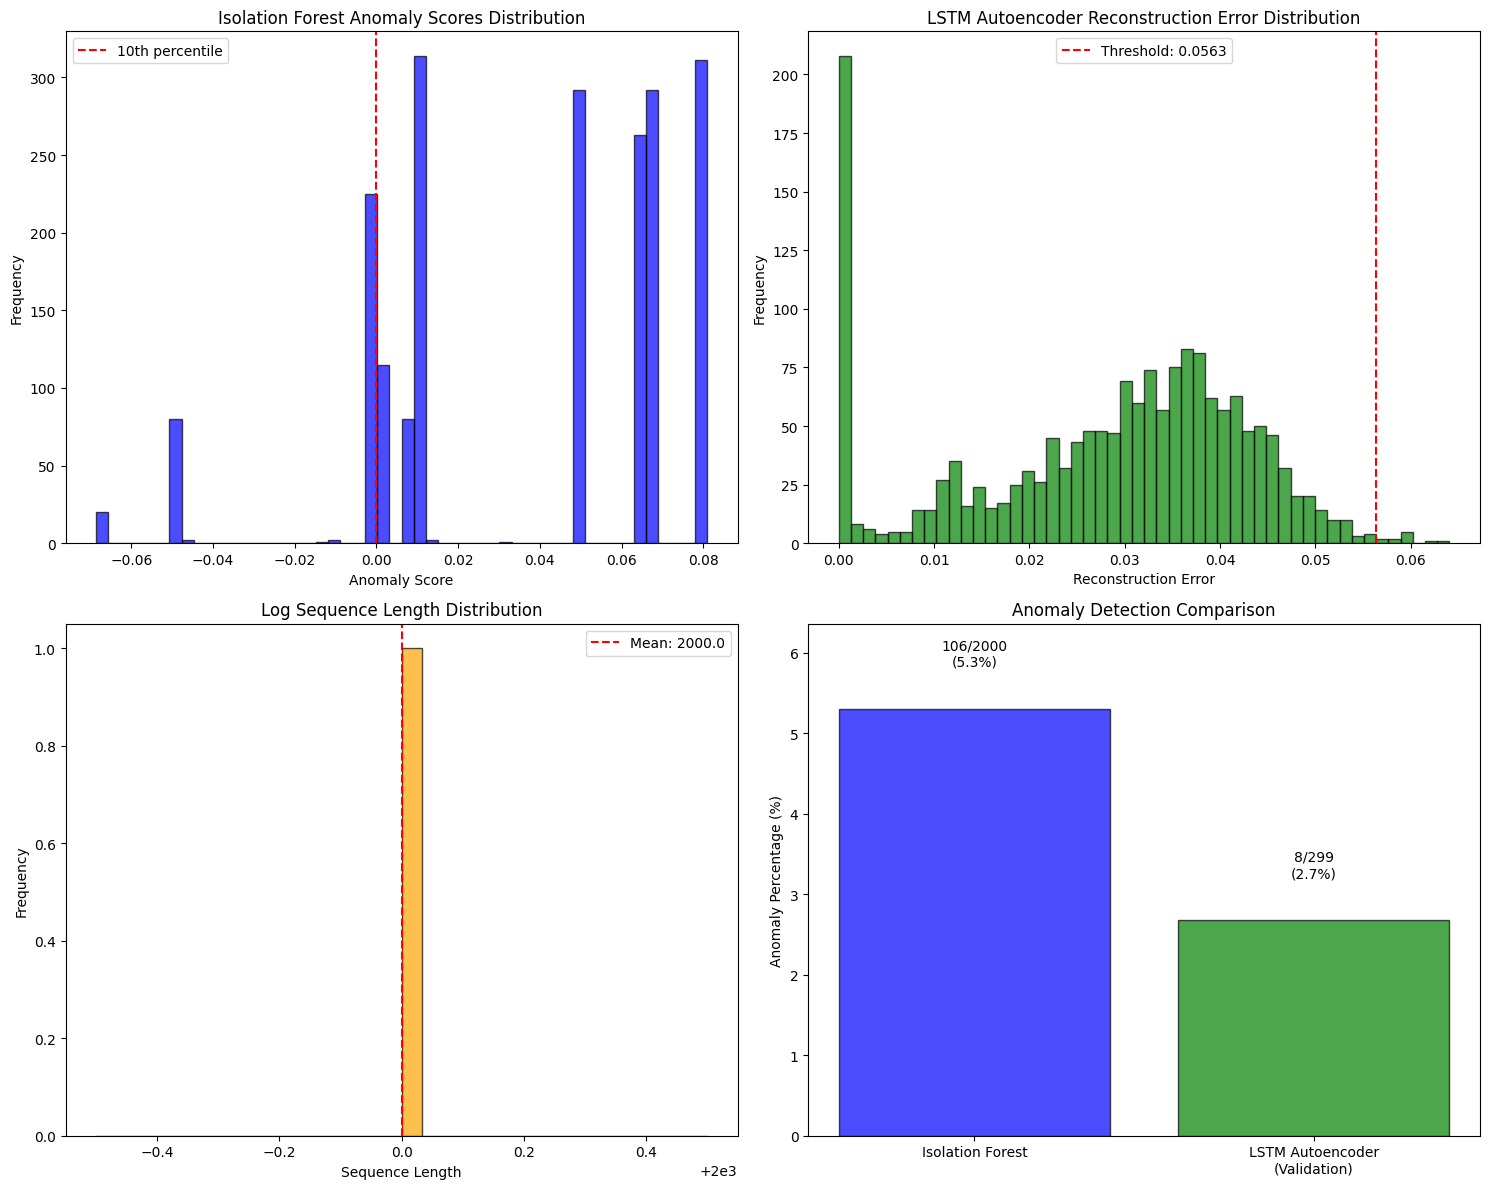

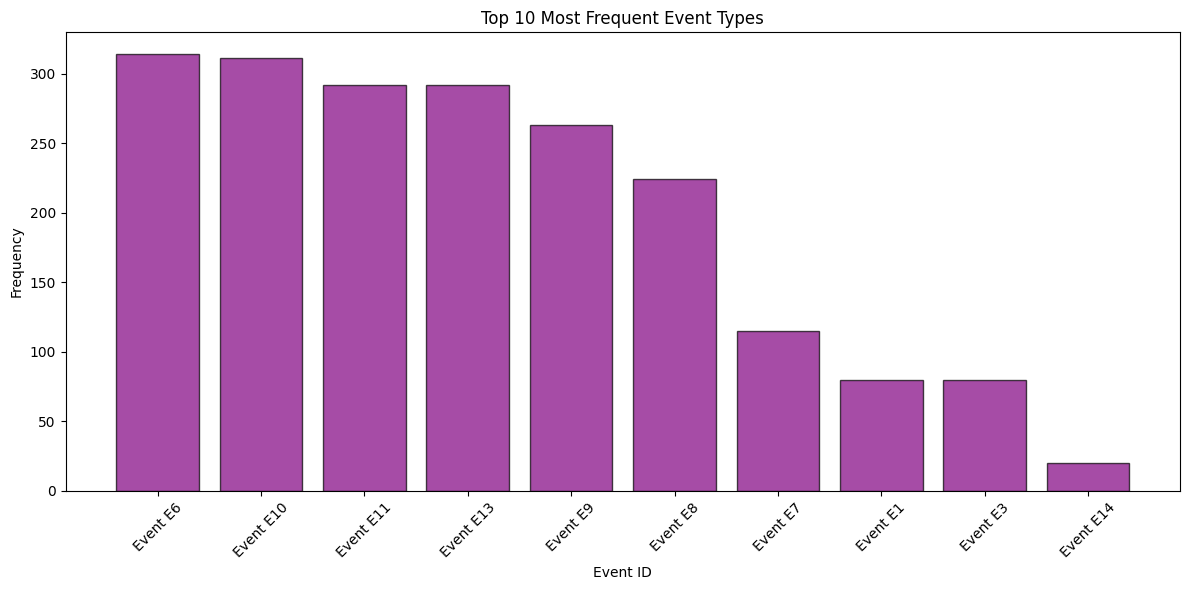

In [25]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Anomaly score distribution (Isolation Forest)
axes[0, 0].hist(tfidf_anomaly_scores, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_title('Isolation Forest Anomaly Scores Distribution')
axes[0, 0].set_xlabel('Anomaly Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(np.percentile(tfidf_anomaly_scores, 10), color='red', linestyle='--', label='10th percentile')
axes[0, 0].legend()

# 2. Reconstruction error distribution (LSTM)
all_errors = np.concatenate([train_errors, val_errors])
axes[0, 1].hist(all_errors, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].axvline(threshold, color='red', linestyle='--', label=f'Threshold: {threshold:.4f}')
axes[0, 1].set_title('LSTM Autoencoder Reconstruction Error Distribution')
axes[0, 1].set_xlabel('Reconstruction Error')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# 3. Sequence length distribution
sequence_lengths = sequences_df['EventId'].apply(len)
axes[1, 0].hist(sequence_lengths, bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1, 0].set_title('Log Sequence Length Distribution')
axes[1, 0].set_xlabel('Sequence Length')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(sequence_lengths.mean(), color='red', linestyle='--', label=f'Mean: {sequence_lengths.mean():.1f}')
axes[1, 0].legend()

# 4. Anomaly detection comparison
methods = ['Isolation Forest', 'LSTM Autoencoder\n(Validation)']
anomaly_counts = [tfidf_anomaly_labels.sum(), val_anomalies.sum()]
total_counts = [len(tfidf_anomaly_labels), len(val_anomalies)]
anomaly_percentages = [count/total*100 for count, total in zip(anomaly_counts, total_counts)]

bars = axes[1, 1].bar(methods, anomaly_percentages, color=['blue', 'green'], alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Anomaly Detection Comparison')
axes[1, 1].set_ylabel('Anomaly Percentage (%)')
axes[1, 1].set_ylim(0, max(anomaly_percentages) * 1.2)

# Add value labels on bars
for bar, count, total in zip(bars, anomaly_counts, total_counts):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{count}/{total}\n({height:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Additional visualization: Event frequency
event_counts = Counter(df['EventId'])
top_events = event_counts.most_common(10)

plt.figure(figsize=(12, 6))
events, counts = zip(*top_events)
plt.bar(range(len(events)), counts, alpha=0.7, color='purple', edgecolor='black')
plt.xticks(range(len(events)), [f'Event {e}' for e in events], rotation=45)
plt.title('Top 10 Most Frequent Event Types')
plt.xlabel('Event ID')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 10. Modular Code

Reusable functions for parsing, preprocessing, training, and inference.

In [26]:
class LogDebugger:
    """
    Modular Log Debugger class with reusable components.
    """

    def __init__(self):
        self.tfidf_vectorizer = None
        self.iso_forest = None
        self.event_encoder = None
        self.autoencoder = None
        self.threshold = None
        self.num_events = None

    def parse_logs(self, log_lines):
        """
        Parse raw log lines into structured format.
        """
        parsed_logs = []
        for log in log_lines:
            parsed = parse_hdfs_log(log)
            parsed_logs.append(parsed)
        return parsed_logs

    def preprocess_logs(self, logs_df):
        """
        Preprocess log dataframe: clean messages and create sequences.
        """
        # Clean messages
        logs_df['cleaned_content'] = logs_df['Content'].apply(clean_log_message)

        # Group by BlockId
        sequences_df = logs_df.groupby('BlockId').agg({
            'EventId': list,
            'cleaned_content': list,
            'Content': list
        }).reset_index()

        return sequences_df

    def create_features(self, logs_df, sequences_df):
        """
        Create TF-IDF and sequence-based features.
        """
        # TF-IDF features
        self.tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2))
        tfidf_features = self.tfidf_vectorizer.fit_transform(logs_df['cleaned_content'])

        # Sequence features
        self.event_encoder = LabelEncoder()
        all_event_ids = logs_df['EventId'].unique()
        self.event_encoder.fit(all_event_ids)
        self.num_events = len(self.event_encoder.classes_)

        return tfidf_features

    def train_baseline_model(self, tfidf_features, contamination=0.1):
        """
        Train Isolation Forest baseline model.
        """
        self.iso_forest = IsolationForest(
            n_estimators=100,
            contamination=contamination,
            random_state=42,
            n_jobs=-1
        )

        # Normalize features (save scaler for inference)
        self.scaler = StandardScaler(with_mean=False)
        tfidf_normalized = self.scaler.fit_transform(tfidf_features)

        self.iso_forest.fit(tfidf_normalized)

        # Get scores
        anomaly_scores = self.iso_forest.decision_function(tfidf_normalized)
        predictions = self.iso_forest.predict(tfidf_normalized)
        anomaly_labels = (predictions == -1).astype(int)

        return anomaly_scores, anomaly_labels

    def train_lstm_autoencoder(self, sequences_df, window_size=10, latent_dim=64, epochs=50):
        """
        Train LSTM Autoencoder for sequence anomaly detection.
        """
        # Ensure event encoder is available
        if self.event_encoder is None:
            if 'EventId' not in sequences_df.columns:
                raise ValueError("EventId column missing from sequences_df. Cannot encode event sequence.")
            unique_events = np.unique([event for seq in sequences_df['EventId'] for event in seq])
            self.event_encoder = LabelEncoder()
            self.event_encoder.fit(unique_events)
            self.num_events = len(self.event_encoder.classes_)

        # Create sliding windows
        sliding_windows = create_sliding_windows(sequences_df['EventId'].tolist(), window_size=window_size)

        # Encode sequences
        encoded_sequences = []
        for seq in sliding_windows:
            encoded_seq = self.event_encoder.transform(seq)
            encoded_sequences.append(encoded_seq)
        encoded_sequences = np.array(encoded_sequences)

        # One-hot encode
        one_hot_sequences = []
        for seq in encoded_sequences:
            one_hot_seq = np.zeros((len(seq), self.num_events))
            for i, event_id in enumerate(seq):
                one_hot_seq[i, event_id] = 1
            one_hot_sequences.append(one_hot_seq)
        one_hot_sequences = np.array(one_hot_sequences)

        # Split data
        train_size = int(0.8 * len(one_hot_sequences))
        train_sequences = one_hot_sequences[:train_size]
        val_sequences = one_hot_sequences[train_size:]

        # Build model
        inputs = Input(shape=(window_size, self.num_events))
        encoded = LSTM(latent_dim, activation='relu')(inputs)
        decoded = RepeatVector(window_size)(encoded)
        decoded = LSTM(latent_dim, activation='relu', return_sequences=True)(decoded)
        decoded = TimeDistributed(Dense(self.num_events, activation='softmax'))(decoded)

        self.autoencoder = Model(inputs, decoded)
        self.autoencoder.compile(optimizer='adam', loss='categorical_crossentropy')

        # Train
        early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        self.autoencoder.fit(
            train_sequences, train_sequences,
            epochs=epochs,
            batch_size=32,
            validation_data=(val_sequences, val_sequences),
            callbacks=[early_stopping],
            verbose=0
        )

        # Calculate threshold
        train_predictions = self.autoencoder.predict(train_sequences, verbose=0)
        train_errors = calculate_reconstruction_error(train_sequences, train_predictions)
        self.threshold = train_errors.mean() + 2 * train_errors.std()

        return train_sequences, val_sequences, train_errors

    def debug_log(self, log_line, method='tfidf'):
        """
        Debug a single log line and return anomaly score + explanation.
        """
        if method == 'tfidf' and self.iso_forest is not None:
            # Validate that TF-IDF vectorizer is available
            if self.tfidf_vectorizer is None:
                return 0.0, "TF-IDF vectorizer is not initialized. Call create_features() before training/inference."

            # Clean and vectorize
            cleaned = clean_log_message(log_line)
            log_vector = self.tfidf_vectorizer.transform([cleaned])

            if self.scaler is not None:
                log_vector_norm = self.scaler.transform(log_vector)
            else:
                log_vector_norm = log_vector

            score = self.iso_forest.decision_function(log_vector_norm)[0]
            is_anomaly = score < 0  # Isolation Forest scores

            explanation = f"Anomaly score: {score:.4f}. "
            if is_anomaly:
                explanation += "This log contains unusual patterns compared to normal logs."
            else:
                explanation += "This log appears normal."

            return score, explanation

        elif method == 'lstm' and self.autoencoder is not None:
            # For LSTM, we need sequence context - this is simplified
            return 0.0, "LSTM debugging requires sequence context. Use debug_sequence instead."

        else:
            return 0.0, "Model not trained or invalid method."

# Initialize and demonstrate the modular debugger
debugger = LogDebugger()

# Ensure vectorizer and encoder are set up before training
debugger.create_features(df, sequences_df)

# Train models
print("Training baseline model...")
tfidf_scores, tfidf_labels = debugger.train_baseline_model(tfidf_features)

print("Training LSTM autoencoder...")
train_seq, val_seq, train_err = debugger.train_lstm_autoencoder(sequences_df)

print("\nTesting debug_log function:")
test_log = df.iloc[0]['Content']
score, explanation = debugger.debug_log(test_log, method='tfidf')
print(f"Log: {test_log[:100]}...")
print(f"Score: {score:.4f}")
print(f"Explanation: {explanation}")

Training baseline model...
Training LSTM autoencoder...

Testing debug_log function:
Log: PacketResponder 1 for block blk_38865049064139660 terminating...
Score: 0.0809
Explanation: Anomaly score: 0.0809. This log appears normal.


## 11. Clean Notebook Structure

This notebook follows a clean, modular structure with clear sections and comprehensive documentation.

## 12. Bonus: Interactive Log Debugger

A simple interactive function for debugging individual logs.

In [27]:
def debug_log_interactive(log_input):
    """
    Interactive function to debug a log line.
    Input can be either a log string or an index in the dataframe.
    """
    if isinstance(log_input, int):
        # Index in dataframe
        if log_input >= len(df):
            return "Error: Index out of range"
        log_line = df.iloc[log_input]['Content']
        log_index = log_input
    elif isinstance(log_input, str):
        # Raw log line
        log_line = log_input
        log_index = None
    else:
        return "Error: Input must be either an integer index or a string log line"

    # Get TF-IDF based debugging
    if log_index is not None:
        tfidf_result = debug_log_tf_idf(log_index)
        score = tfidf_result['anomaly_score']
        explanation = tfidf_result['explanation']
    else:
        # For raw logs not in dataset, use the modular debugger
        score, explanation = debugger.debug_log(log_line, method='tfidf')

    # Format output
    output = f"""
🔍 LOG DEBUGGER RESULTS
{'='*50}

📝 Original Log:
{log_line}

🎯 Anomaly Score: {score:.4f}
📊 Status: {'🚨 ANOMALY DETECTED' if score < 0 else '✅ NORMAL LOG'}

💡 Explanation:
{explanation}

{'🔴 HIGH PRIORITY: This log requires immediate attention!' if score < -0.5 else '🟡 MONITOR: This log shows some unusual patterns.' if score < 0 else '🟢 NORMAL: This log follows expected patterns.'}
"""

    return output

# Demo the interactive debugger
print("=== Interactive Log Debugger Demo ===")

# Test with a normal log
print(debug_log_interactive(0))

print("\n" + "="*60 + "\n")

# Test with a potentially anomalous log (find one with high anomaly score)
anomaly_indices = np.where(tfidf_anomaly_scores < np.percentile(tfidf_anomaly_scores, 10))[0]
if len(anomaly_indices) > 0:
    print(debug_log_interactive(anomaly_indices[0]))

# Test with raw log input
print("\n" + "="*60 + "\n")
raw_log = "2023-01-01 12:00:00,001 12345 INFO dfs.DataNode: blk_-123456789 receiving block blk_-123456789 src: /10.0.0.1:50010 dest: /10.0.0.2:50010"
print(debug_log_interactive(raw_log))

print("\n🎉 Log Debugger System Complete!")
print("You can now use debug_log_interactive() to analyze any HDFS log line!")

=== Interactive Log Debugger Demo ===

🔍 LOG DEBUGGER RESULTS

📝 Original Log:
PacketResponder 1 for block blk_38865049064139660 terminating

🎯 Anomaly Score: 0.0809
📊 Status: ✅ NORMAL LOG

💡 Explanation:
This log appears normal (score: 0.0809).

🟢 NORMAL: This log follows expected patterns.



Error: Input must be either an integer index or a string log line



🔍 LOG DEBUGGER RESULTS

📝 Original Log:
2023-01-01 12:00:00,001 12345 INFO dfs.DataNode: blk_-123456789 receiving block blk_-123456789 src: /10.0.0.1:50010 dest: /10.0.0.2:50010

🎯 Anomaly Score: 0.0397
📊 Status: ✅ NORMAL LOG

💡 Explanation:
Anomaly score: 0.0397. This log appears normal.

🟢 NORMAL: This log follows expected patterns.


🎉 Log Debugger System Complete!
You can now use debug_log_interactive() to analyze any HDFS log line!
